Adjusted-price data loaded.
Date range: 1996-10-30 to 2026-08-21
Available tickers: 12

ANALYSING GROUP_1
Usable observations: 7,182 from 1998-07-27 to 2026-08-21
group_1: completed 100 / 6,932 forecasts
group_1: completed 200 / 6,932 forecasts
group_1: completed 300 / 6,932 forecasts
group_1: completed 400 / 6,932 forecasts
group_1: completed 500 / 6,932 forecasts
group_1: completed 600 / 6,932 forecasts
group_1: completed 700 / 6,932 forecasts
group_1: completed 800 / 6,932 forecasts
group_1: completed 900 / 6,932 forecasts
group_1: completed 1,000 / 6,932 forecasts
group_1: completed 1,100 / 6,932 forecasts
group_1: completed 1,200 / 6,932 forecasts
group_1: completed 1,300 / 6,932 forecasts
group_1: completed 1,400 / 6,932 forecasts
group_1: completed 1,500 / 6,932 forecasts
group_1: completed 1,600 / 6,932 forecasts
group_1: completed 1,700 / 6,932 forecasts
group_1: completed 1,800 / 6,932 forecasts
group_1: completed 1,900 / 6,932 forecasts
group_1: completed 2,000 / 6,932 forec

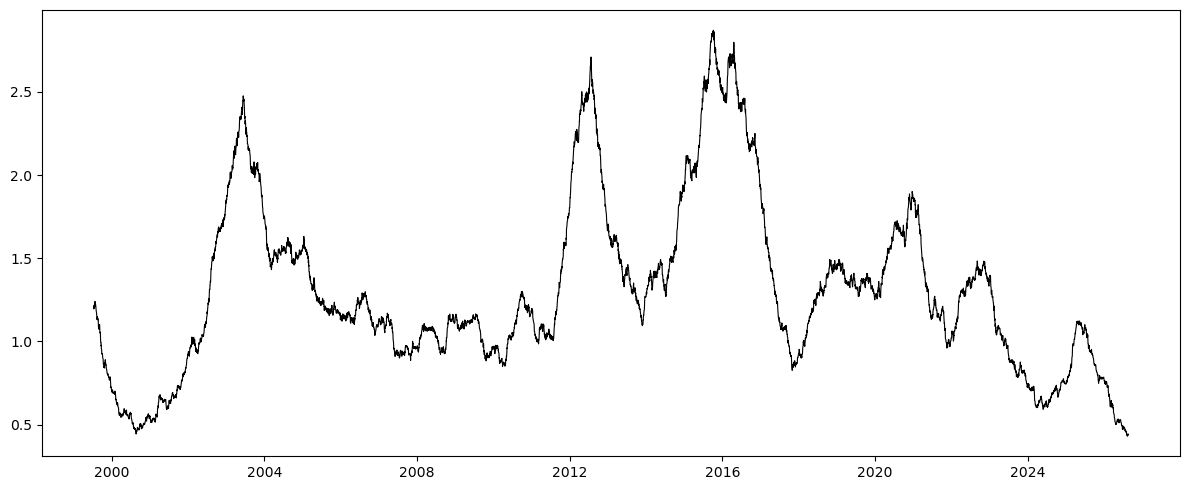

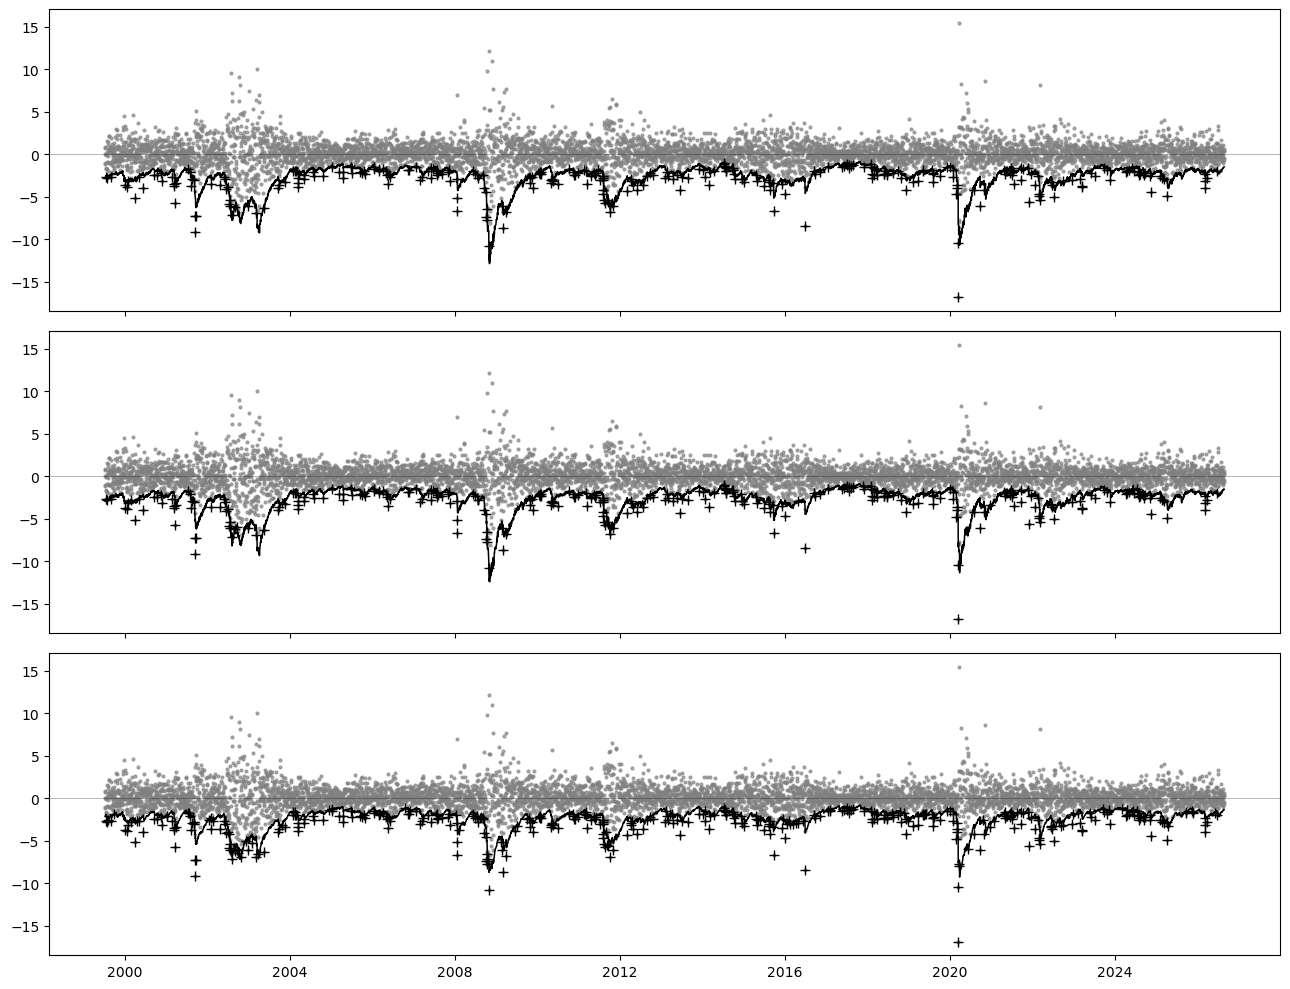


Aggregate backtesting statistics:
method  alpha  average_exceedance_ratio  squared_distance_sum  relative_distance
    RM   0.05                  0.057381              0.006086           1.560263
    RM   0.01                  0.019445              0.009115           9.547086
    MW   0.05                  0.045547              0.002403           0.980431
    MW   0.01                  0.007186              0.000914           3.022643
   LCP   0.05                  0.045591              0.002371           0.973939
   LCP   0.01                  0.007213              0.000899           2.997645

group_1 completed successfully.

ANALYSING GROUP_2
Usable observations: 6,804 from 2000-01-06 to 2026-08-21
group_2: completed 100 / 6,554 forecasts
group_2: completed 200 / 6,554 forecasts
group_2: completed 300 / 6,554 forecasts
group_2: completed 400 / 6,554 forecasts
group_2: completed 500 / 6,554 forecasts
group_2: completed 600 / 6,554 forecasts
group_2: completed 700 / 6,554 forecasts
gr

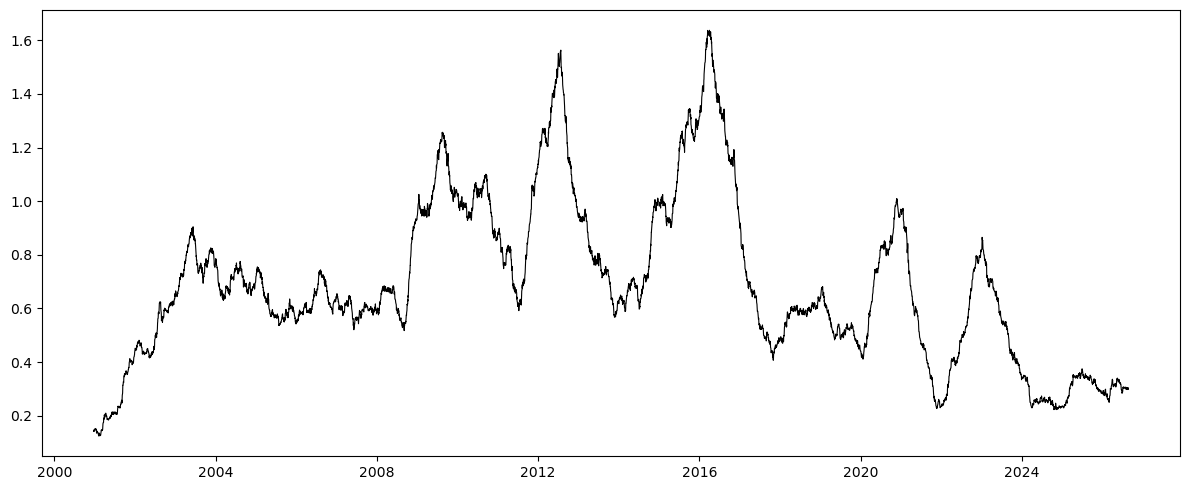

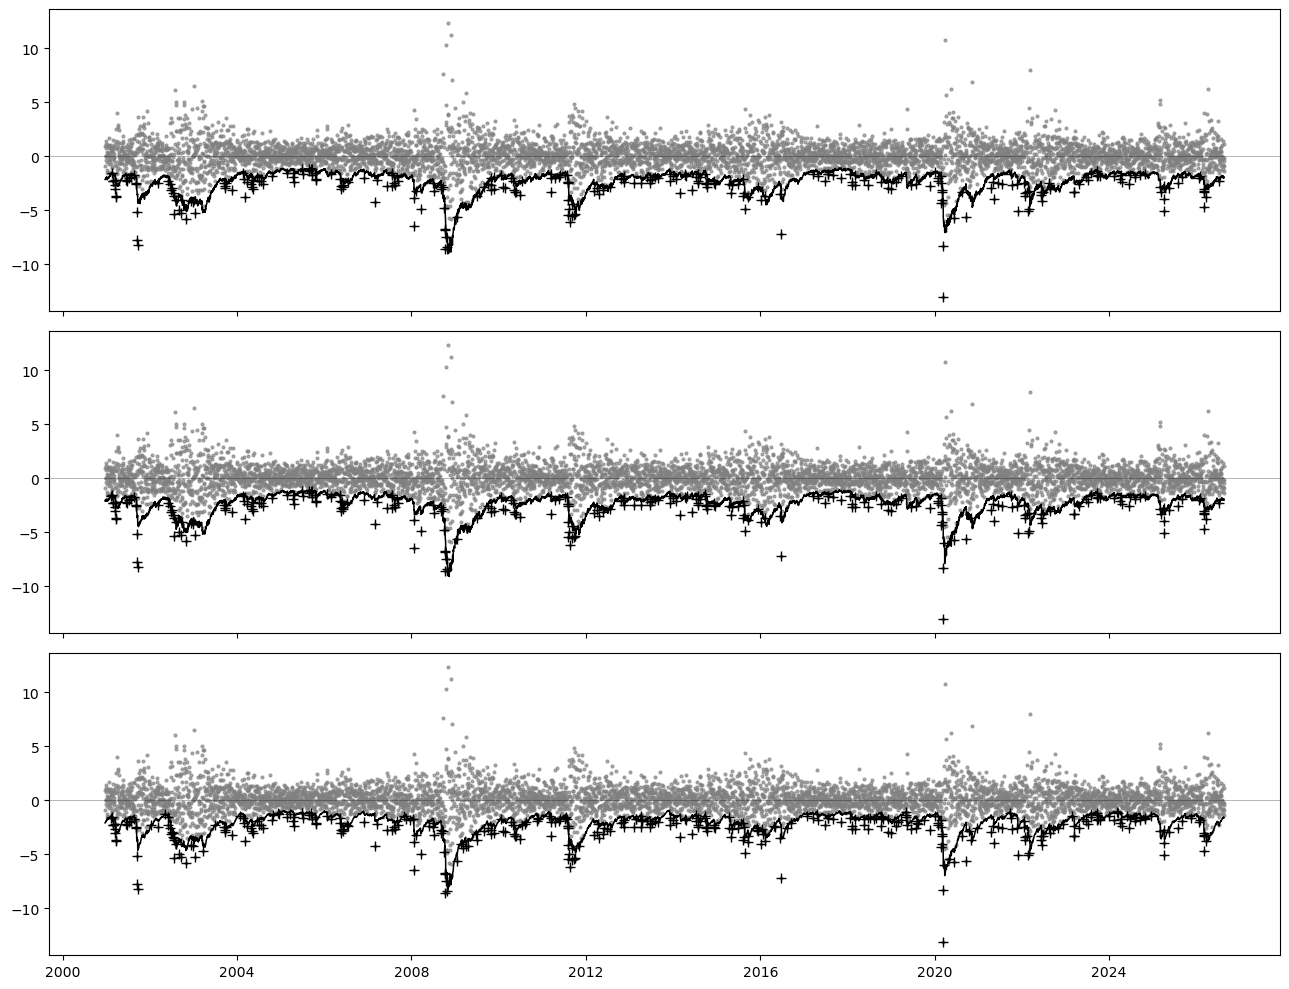


Aggregate backtesting statistics:
method  alpha  average_exceedance_ratio  squared_distance_sum  relative_distance
    RM   0.05                  0.056088              0.004023           1.268599
    RM   0.01                  0.019513              0.009244           9.614379
    MW   0.05                  0.046373              0.002409           0.981599
    MW   0.01                  0.007405              0.000920           3.033072
   LCP   0.05                  0.046503              0.002327           0.964678
   LCP   0.01                  0.007419              0.000888           2.979144

group_2 completed successfully.

ALL GROUPS COMPLETED


In [3]:
# pip install pandas numpy scipy matplotlib

from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kendalltau, norm


# ============================================================
# 1. Paths and global settings
# ============================================================

DATA_FILE = Path("../Data/german_stocks_daily_ohlcv.csv")

# Numerical outputs: CSV files
OUTPUT_DIR = Path("../Data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Figures: current working directory
FIGURE_DIR = Path(".")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. Model settings
# ============================================================

# RiskMetrics exponential-volatility specification:
# lambda = 1/20 on the slides.
LAMBDA = 1 / 20
DECAY = np.exp(-LAMBDA)

# VaR confidence-tail levels.
ALPHA_LEVELS = [0.05, 0.01]

# Monte Carlo simulations for the Clayton-copula VaR forecasts.
# Raise to 10_000 or 20_000 for a final research run.
N_SIMULATIONS = 5_000

# Fixed historical window for Moving Window (MW) Clayton estimation.
MW_WINDOW = 250

# LCP settings displayed in Figure 51.
LCP_M0 = 20
LCP_C = 1.25
LCP_RHO = 0.5
LCP_MAX_WINDOW = 250

# The adaptive LCP acceptance threshold.
# This is an explicit practical calibration because the slides do
# not provide the original LCP test statistic / critical values.
LCP_Z_THRESHOLD = 1 / LCP_RHO

# Minimum valid observations for Clayton-parameter estimation.
MIN_COPULA_OBSERVATIONS = 15

# Use the same forecast start for RM, MW, and LCP.
# This makes the methods directly comparable over identical dates.
FORECAST_START = max(MW_WINDOW, 60)

# Portfolios used for backtesting:
# one equal-weighted portfolio + 100 random long-only portfolios.
N_RANDOM_PORTFOLIOS = 100
RANDOM_SEED = 42

# Clayton copula must have theta > 0.
THETA_FLOOR = 1e-8


# ============================================================
# 3. Define the two stock groups
# ============================================================

groups = {
    "group_1": {
        "Volkswagen_pref": "VOW3.DE",
        "Mercedes_Benz_Group": "MBG.DE",
        "Allianz": "ALV.DE",
        "Munich_Re": "MUV2.DE",
        "Bayer": "BAYN.DE",
        "BASF": "BAS.DE",
    },
    "group_2": {
        "Siemens": "SIE.DE",
        "EON": "EOAN.DE",
        "thyssenkrupp": "TKA.DE",
        "Lufthansa": "LHA.DE",
        "Merck_KGaA": "MRK.DE",
        "Henkel_pref": "HEN3.DE",
    },
}


# ============================================================
# 4. Data functions
# ============================================================

def load_adjusted_price_panel(csv_file):
    """
    Read the long-format Yahoo Finance CSV and pivot it into
    a date x ticker adjusted-close price panel.
    """

    data = pd.read_csv(csv_file, parse_dates=["date"])

    required_columns = {"date", "ticker", "adj_close"}
    missing = required_columns.difference(data.columns)

    if missing:
        raise ValueError(
            f"CSV is missing required columns: {sorted(missing)}"
        )

    prices = (
        data
        .pivot_table(
            index="date",
            columns="ticker",
            values="adj_close",
            aggfunc="last",
        )
        .sort_index()
    )

    return prices


def compute_log_returns(price_panel):
    """
    X_{t,j} = log(P_{t,j} / P_{t-1,j})
    """

    return np.log(price_panel / price_panel.shift(1))


# ============================================================
# 5. RiskMetrics volatility functions
# ============================================================

def compute_ewma_volatility_and_residuals(log_returns, decay):
    """
    Estimate conditional volatility using the exponential weighting
    implied by lambda = 1/20.

    sigma_t^2 uses returns available through t-1 only:

        sigma_t^2 =
        (1 - decay) * sum_{s < t} decay^(t-1-s) * X_s^2

    Standardized residual:

        epsilon_t = X_t / sigma_t
    """

    squared_returns = log_returns.pow(2)

    conditional_variance = (
        squared_returns
        .shift(1)
        .ewm(
            alpha=1 - decay,
            adjust=False,
            min_periods=2,
        )
        .mean()
    )

    conditional_volatility = np.sqrt(conditional_variance)

    standardized_residuals = (
        log_returns / conditional_volatility
    ).replace([np.inf, -np.inf], np.nan)

    return conditional_volatility, standardized_residuals


def compute_ewma_covariance_forecasts(return_array, decay):
    """
    Produce one-step-ahead RiskMetrics covariance forecasts.

    covariance[t] is based on observations strictly before t.
    Therefore, it can be used for the VaR forecast at time t.
    """

    n_dates, n_assets = return_array.shape

    covariance_forecasts = np.empty(
        (n_dates, n_assets, n_assets)
    )

    covariance = np.outer(return_array[0], return_array[0])

    for t in range(n_dates):

        covariance_forecasts[t] = covariance.copy()

        covariance = (
            decay * covariance
            + (1 - decay) * np.outer(
                return_array[t],
                return_array[t],
            )
        )

    return covariance_forecasts


# ============================================================
# 6. Clayton-copula estimation functions
# ============================================================

def estimate_clayton_theta(residual_window):
    """
    Estimate a one-parameter Clayton copula.

    Steps:
    1. Calculate all pairwise Kendall tau values.
    2. Average the pairwise values.
    3. Convert the average tau to Clayton theta:

         theta = 2 * tau / (1 - tau)

    The six-dimensional Clayton copula has one common theta parameter.
    """

    clean_window = residual_window.dropna(how="any")

    if len(clean_window) < MIN_COPULA_OBSERVATIONS:
        return np.nan, np.nan, 0

    pairwise_taus = []

    for asset_i, asset_j in combinations(clean_window.columns, 2):

        tau, _ = kendalltau(
            clean_window[asset_i],
            clean_window[asset_j],
            nan_policy="omit",
        )

        if np.isfinite(tau):
            pairwise_taus.append(tau)

    if len(pairwise_taus) == 0:
        return np.nan, np.nan, len(clean_window)

    average_tau = float(np.mean(pairwise_taus))

    # Clayton copulas model positive lower-tail dependence.
    if average_tau <= 0:
        theta = THETA_FLOOR
    else:
        theta = 2 * average_tau / (1 - average_tau)
        theta = max(theta, THETA_FLOOR)

    return theta, average_tau, len(clean_window)


def approximate_theta_standard_error(theta, tau, n_obs):
    """
    Approximate uncertainty of theta estimated through Kendall's tau.

    This is used only for adaptive LCP-style window selection.
    It is not used in the MW estimator itself.
    """

    if (
        not np.isfinite(theta)
        or not np.isfinite(tau)
        or n_obs < 5
    ):
        return np.inf

    # Large-sample standard error approximation for Kendall tau.
    se_tau = np.sqrt(
        2 * (2 * n_obs + 5)
        / (9 * n_obs * (n_obs - 1))
    )

    # d theta / d tau for theta = 2*tau/(1-tau)
    derivative = 2 / (1 - tau) ** 2

    return derivative * se_tau


def create_lcp_candidate_windows(
    m0=LCP_M0,
    c=LCP_C,
    max_window=LCP_MAX_WINDOW,
):
    """
    Construct:

        m_k = floor(m0 * c^k)

    Example:
        20, 25, 31, 39, 49, 61, ...
    """

    windows = [m0]
    current_window = m0

    while current_window < max_window:
        next_window = int(np.floor(current_window * c))

        if next_window <= current_window:
            next_window = current_window + 1

        if next_window > max_window:
            next_window = max_window

        if next_window == windows[-1]:
            break

        windows.append(next_window)
        current_window = next_window

    return sorted(set(windows))


LCP_CANDIDATE_WINDOWS = create_lcp_candidate_windows()


def select_lcp_window(residual_history):
    """
    Adaptive LCP-style local-window selection.

    The procedure starts from m0 = 20 and progressively tests
    larger candidate windows. A larger window is retained if the
    change in the estimated Clayton parameter is not too large
    relative to its approximate estimation uncertainty.

    Returns:
        selected_window
        selected_theta
        selected_average_tau
    """

    history_length = len(residual_history)

    feasible_windows = [
        window
        for window in LCP_CANDIDATE_WINDOWS
        if window <= history_length
    ]

    if not feasible_windows:
        return np.nan, np.nan, np.nan

    first_window = feasible_windows[0]

    previous_window_data = residual_history.iloc[-first_window:]
    previous_theta, previous_tau, previous_n = (
        estimate_clayton_theta(previous_window_data)
    )

    if not np.isfinite(previous_theta):
        return np.nan, np.nan, np.nan

    selected_window = first_window
    selected_theta = previous_theta
    selected_tau = previous_tau

    for candidate_window in feasible_windows[1:]:

        candidate_data = residual_history.iloc[-candidate_window:]

        candidate_theta, candidate_tau, candidate_n = (
            estimate_clayton_theta(candidate_data)
        )

        if not np.isfinite(candidate_theta):
            break

        previous_se = approximate_theta_standard_error(
            previous_theta,
            previous_tau,
            previous_n,
        )

        candidate_se = approximate_theta_standard_error(
            candidate_theta,
            candidate_tau,
            candidate_n,
        )

        difference = abs(candidate_theta - previous_theta)

        pooled_se = np.sqrt(
            previous_se ** 2 + candidate_se ** 2
        )

        if pooled_se == 0 or not np.isfinite(pooled_se):
            break

        z_statistic = difference / pooled_se

        # Accept the longer interval only when it remains locally homogeneous.
        if z_statistic <= LCP_Z_THRESHOLD:
            selected_window = candidate_window
            selected_theta = candidate_theta
            selected_tau = candidate_tau

            previous_theta = candidate_theta
            previous_tau = candidate_tau
            previous_n = candidate_n

        else:
            break

    return selected_window, selected_theta, selected_tau


# ============================================================
# 7. Clayton-copula simulation functions
# ============================================================

def simulate_clayton_uniforms(theta, n_simulations, n_assets, rng):
    """
    Simulate from a d-dimensional Clayton copula.

    Frailty representation:

        W ~ Gamma(1/theta, 1)
        E_j ~ Exponential(1)

        U_j = (1 + E_j / W)^(-1/theta)

    When theta is effectively zero, simulate independent uniforms.
    """

    if theta <= 1e-6:

        return rng.uniform(
            low=0.0,
            high=1.0,
            size=(n_simulations, n_assets),
        )

    frailty = rng.gamma(
        shape=1 / theta,
        scale=1.0,
        size=n_simulations,
    )

    exponentials = rng.exponential(
        scale=1.0,
        size=(n_simulations, n_assets),
    )

    uniforms = (
        1 + exponentials / frailty[:, None]
    ) ** (-1 / theta)

    return uniforms


def uniforms_to_empirical_residuals(
    uniforms,
    residual_window,
):
    """
    Transform Clayton-copula uniform draws into residual draws,
    using each stock's empirical residual distribution.
    """

    residual_array = residual_window.to_numpy()

    n_simulations, n_assets = uniforms.shape

    simulated_residuals = np.empty(
        (n_simulations, n_assets)
    )

    for j in range(n_assets):

        simulated_residuals[:, j] = np.quantile(
            residual_array[:, j],
            uniforms[:, j],
            method="linear",
        )

    return simulated_residuals


def simulate_portfolio_returns(
    theta,
    residual_window,
    next_volatility,
    portfolio_weights,
    n_simulations,
    rng,
):
    """
    Simulate asset returns and portfolio P&L / returns.

    Simulated asset return:
        X_{t+1,j} = sigma_{t+1,j} * epsilon_{t+1,j}

    Simulated portfolio return:
        L_{t+1}(w) = w' X_{t+1}
    """

    n_assets = residual_window.shape[1]

    simulated_uniforms = simulate_clayton_uniforms(
        theta=theta,
        n_simulations=n_simulations,
        n_assets=n_assets,
        rng=rng,
    )

    simulated_residuals = uniforms_to_empirical_residuals(
        uniforms=simulated_uniforms,
        residual_window=residual_window,
    )

    simulated_asset_returns = (
        simulated_residuals
        * next_volatility[None, :]
    )

    simulated_portfolio_returns = (
        simulated_asset_returns @ portfolio_weights.T
    )

    return simulated_portfolio_returns


# ============================================================
# 8. Portfolio and backtesting functions
# ============================================================

def create_portfolios(n_assets, n_random, seed):
    """
    Create:
    - w_star: equally weighted six-stock portfolio;
    - w_1,...,w_100: random long-only portfolios.

    Dirichlet(1,...,1) is uniform on the unit simplex.
    """

    rng = np.random.default_rng(seed)

    w_star = np.repeat(1 / n_assets, n_assets)

    random_weights = rng.dirichlet(
        alpha=np.ones(n_assets),
        size=n_random,
    )

    weights = np.vstack([w_star, random_weights])

    portfolio_names = (
        ["w_star"]
        + [f"w_{i}" for i in range(1, n_random + 1)]
    )

    return weights, portfolio_names


def calculate_backtest_statistics(
    realized_returns,
    var_forecasts,
    alpha_levels,
    portfolio_names,
):
    """
    Calculate:

        alpha_hat_w
        A^W
        S^W
        D^W

    Inputs:
    - realized_returns: shape (T, n_portfolios)
    - var_forecasts: shape (T, n_portfolios, n_alpha)
    """

    rows = []

    n_periods, n_portfolios = realized_returns.shape

    for alpha_index, alpha in enumerate(alpha_levels):

        exceedances = (
            realized_returns
            < var_forecasts[:, :, alpha_index]
        )

        alpha_hat = exceedances.mean(axis=0)

        # Statistics for individual portfolios.
        for portfolio_index, portfolio_name in enumerate(portfolio_names):

            rows.append({
                "portfolio": portfolio_name,
                "alpha": alpha,
                "exceedance_ratio": alpha_hat[portfolio_index],
                "exceedance_ratio_pct": (
                    100 * alpha_hat[portfolio_index]
                ),
                "average_exceedance_ratio": np.nan,
                "squared_distance_sum": np.nan,
                "relative_distance": np.nan,
                "n_forecasts": n_periods,
            })

        # Aggregate statistics across W = {w_star, w_1, ..., w_100}.
        average_exceedance_ratio = alpha_hat.mean()

        squared_distance_sum = np.sum(
            (alpha_hat - alpha) ** 2
        )

        relative_distance = (
            np.sqrt(squared_distance_sum) / alpha
        )

        rows.append({
            "portfolio": "ALL_PORTFOLIOS",
            "alpha": alpha,
            "exceedance_ratio": np.nan,
            "exceedance_ratio_pct": np.nan,
            "average_exceedance_ratio": average_exceedance_ratio,
            "squared_distance_sum": squared_distance_sum,
            "relative_distance": relative_distance,
            "n_forecasts": n_periods,
        })

    return pd.DataFrame(rows)


# ============================================================
# 9. Plotting functions
# ============================================================


def plot_time_varying_theta(theta_frame, group_name):

    fig, ax = plt.subplots(figsize=(12, 5))

    # Make the entire figure and plotting area transparent.
    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)

    ax.plot(
        theta_frame.index,
        theta_frame["theta_lcp"],
        color="black",
        linewidth=0.8,
    )

    # Keep the axes, tick marks, and numerical/date tick labels.

    fig.tight_layout()

    file_path = (
        FIGURE_DIR
        / f"{group_name}_lcp_clayton_theta.png"
    )

    fig.savefig(
        file_path,
        dpi=300,
        bbox_inches="tight",
        transparent=True,
    )

    plt.show()
    plt.close(fig)


def plot_var_backtests(
    dates,
    realized_returns_wstar,
    var_rm,
    var_mw,
    var_lcp,
    group_name,
    alpha=0.05,
):

    methods = [
        ("LCP", var_lcp),
        ("MW", var_mw),
        ("RM", var_rm),
    ]

    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(13, 10),
        sharex=True,
    )

    # Transparent overall figure background.
    fig.patch.set_alpha(0)

    for ax, (method_name, var_series) in zip(axes, methods):

        # Transparent individual subplot background.
        ax.patch.set_alpha(0)

        exceedances = (
            realized_returns_wstar < var_series
        )

        # Realised portfolio returns / P&L.
        ax.scatter(
            dates,
            realized_returns_wstar * 100,
            s=4,
            color="gray",
            alpha=0.65,
        )

        # VaR forecast.
        ax.plot(
            dates,
            var_series * 100,
            color="black",
            linewidth=1.1,
        )

        # VaR exceedances.
        ax.scatter(
            dates[exceedances],
            realized_returns_wstar[exceedances] * 100,
            marker="+",
            s=45,
            linewidths=1.0,
            color="black",
        )

        # Horizontal zero-return reference line.
        ax.axhline(
            y=0,
            color="black",
            linewidth=0.5,
            alpha=0.4,
        )

        # No title, labels, legend, or grid:
        # no ax.set_title(...)
        # no ax.set_ylabel(...)
        # no ax.set_xlabel(...)
        # no ax.legend(...)
        # no ax.grid(...)

    # Do not use axes[-1].set_xlabel("Date").
    # The date tick labels remain visible on the bottom subplot.

    fig.tight_layout()

    file_path = (
        FIGURE_DIR
        / f"{group_name}_var_backtest_alpha_{int(alpha * 100)}.png"
    )

    fig.savefig(
        file_path,
        dpi=300,
        bbox_inches="tight",
        transparent=True,
    )

    plt.show()
    plt.close(fig)


# ============================================================
# 10. Main group-analysis function
# ============================================================

def analyse_group(group_name, company_to_ticker):
    """
    Run the complete RM, MW, and LCP-style Clayton VaR workflow
    for one six-stock group.
    """

    print("\n" + "=" * 70)
    print(f"ANALYSING {group_name.upper()}")
    print("=" * 70)

    group_tickers = list(company_to_ticker.values())

    missing_tickers = [
        ticker
        for ticker in group_tickers
        if ticker not in adjusted_prices.columns
    ]

    if missing_tickers:
        raise ValueError(
            f"{group_name}: missing tickers in CSV: {missing_tickers}"
        )

    # --------------------------------------------------------
    # 10.1 Select common adjusted-price observations
    # --------------------------------------------------------

    prices = (
        adjusted_prices[group_tickers]
        .dropna(how="any")
        .copy()
    )

    prices = prices.rename(
        columns={
            ticker: company
            for company, ticker in company_to_ticker.items()
        }
    )

    log_returns = compute_log_returns(prices)

    conditional_volatility, residuals = (
        compute_ewma_volatility_and_residuals(
            log_returns=log_returns,
            decay=DECAY,
        )
    )

    # Keep only dates at which all six residuals and volatilities exist.
    valid_dates = residuals.dropna(how="any").index

    returns = log_returns.loc[valid_dates].copy()
    volatility = conditional_volatility.loc[valid_dates].copy()
    residuals = residuals.loc[valid_dates].copy()

    if len(returns) <= FORECAST_START:
        raise ValueError(
            f"{group_name}: insufficient common data after filtering. "
            f"Need more than {FORECAST_START} valid observations, "
            f"but only {len(returns)} remain."
        )

    print(
        f"Usable observations: {len(returns):,} "
        f"from {returns.index.min().date()} "
        f"to {returns.index.max().date()}"
    )

    n_assets = returns.shape[1]

    # --------------------------------------------------------
    # 10.2 Construct portfolios
    # --------------------------------------------------------

    portfolio_weights, portfolio_names = create_portfolios(
        n_assets=n_assets,
        n_random=N_RANDOM_PORTFOLIOS,
        seed=RANDOM_SEED,
    )

    n_portfolios = len(portfolio_names)
    n_alpha = len(ALPHA_LEVELS)

    portfolio_weights_frame = pd.DataFrame(
        portfolio_weights,
        index=portfolio_names,
        columns=returns.columns,
    )

    portfolio_weights_frame.to_csv(
        OUTPUT_DIR / f"{group_name}_portfolio_weights.csv"
    )

    # --------------------------------------------------------
    # 10.3 RiskMetrics covariance forecasts
    # --------------------------------------------------------

    return_array = returns.to_numpy()

    ewma_covariances = compute_ewma_covariance_forecasts(
        return_array=return_array,
        decay=DECAY,
    )

    # --------------------------------------------------------
    # 10.4 Allocate output arrays
    # --------------------------------------------------------

    forecast_dates = returns.index[FORECAST_START:]
    n_forecasts = len(forecast_dates)

    realized_portfolio_returns = np.empty(
        (n_forecasts, n_portfolios)
    )

    var_rm = np.empty(
        (n_forecasts, n_portfolios, n_alpha)
    )

    var_mw = np.empty(
        (n_forecasts, n_portfolios, n_alpha)
    )

    var_lcp = np.empty(
        (n_forecasts, n_portfolios, n_alpha)
    )

    theta_records = []

    rng = np.random.default_rng(RANDOM_SEED + 100)

    # --------------------------------------------------------
    # 10.5 Rolling one-step-ahead VaR forecasting
    # --------------------------------------------------------

    for output_position, t in enumerate(
        range(FORECAST_START, len(returns))
    ):

        forecast_date = returns.index[t]

        # History ends at t-1, so the forecast does not use date-t information.
        residual_history = residuals.iloc[:t]

        next_volatility = volatility.iloc[t].to_numpy()

        realized_asset_returns = returns.iloc[t].to_numpy()

        realized_portfolio_returns[output_position] = (
            realized_asset_returns @ portfolio_weights.T
        )

        # ----------------------------------------------------
        # RM: parametric Gaussian RiskMetrics VaR
        # ----------------------------------------------------

        covariance_t = ewma_covariances[t]

        portfolio_variance = np.einsum(
            "pi,ij,pj->p",
            portfolio_weights,
            covariance_t,
            portfolio_weights,
        )

        portfolio_standard_deviation = np.sqrt(
            np.maximum(portfolio_variance, 0)
        )

        for alpha_index, alpha in enumerate(ALPHA_LEVELS):

            var_rm[output_position, :, alpha_index] = (
                norm.ppf(alpha)
                * portfolio_standard_deviation
            )

        # ----------------------------------------------------
        # MW: fixed 250-day Clayton-copula estimation
        # ----------------------------------------------------

        mw_residual_window = residual_history.iloc[-MW_WINDOW:]

        theta_mw, tau_mw, n_mw = estimate_clayton_theta(
            mw_residual_window
        )

        if not np.isfinite(theta_mw):
            theta_mw = THETA_FLOOR

        simulated_mw_portfolio_returns = (
            simulate_portfolio_returns(
                theta=theta_mw,
                residual_window=mw_residual_window,
                next_volatility=next_volatility,
                portfolio_weights=portfolio_weights,
                n_simulations=N_SIMULATIONS,
                rng=rng,
            )
        )

        for alpha_index, alpha in enumerate(ALPHA_LEVELS):

            var_mw[output_position, :, alpha_index] = (
                np.quantile(
                    simulated_mw_portfolio_returns,
                    q=alpha,
                    axis=0,
                    method="linear",
                )
            )

        # ----------------------------------------------------
        # LCP: adaptive local Clayton-copula estimation
        # ----------------------------------------------------

        selected_lcp_window, theta_lcp, tau_lcp = (
            select_lcp_window(residual_history)
        )

        if not np.isfinite(theta_lcp):
            selected_lcp_window = LCP_M0
            theta_lcp = THETA_FLOOR
            tau_lcp = 0.0

        lcp_residual_window = residual_history.iloc[
            -int(selected_lcp_window):
        ]

        simulated_lcp_portfolio_returns = (
            simulate_portfolio_returns(
                theta=theta_lcp,
                residual_window=lcp_residual_window,
                next_volatility=next_volatility,
                portfolio_weights=portfolio_weights,
                n_simulations=N_SIMULATIONS,
                rng=rng,
            )
        )

        for alpha_index, alpha in enumerate(ALPHA_LEVELS):

            var_lcp[output_position, :, alpha_index] = (
                np.quantile(
                    simulated_lcp_portfolio_returns,
                    q=alpha,
                    axis=0,
                    method="linear",
                )
            )

        # ----------------------------------------------------
        # Store time-varying dependence estimates
        # ----------------------------------------------------

        theta_records.append({
            "date": forecast_date,
            "theta_mw": theta_mw,
            "tau_mw": tau_mw,
            "mw_window": MW_WINDOW,
            "theta_lcp": theta_lcp,
            "tau_lcp": tau_lcp,
            "lcp_selected_window": selected_lcp_window,
        })

        if (output_position + 1) % 100 == 0:
            print(
                f"{group_name}: completed "
                f"{output_position + 1:,} / {n_forecasts:,} forecasts"
            )

    # --------------------------------------------------------
    # 10.6 Save theta series and Figure 51 output
    # --------------------------------------------------------

    theta_frame = (
        pd.DataFrame(theta_records)
        .set_index("date")
    )

    theta_frame.to_csv(
        OUTPUT_DIR / f"{group_name}_clayton_theta_series.csv"
    )

    plot_time_varying_theta(
        theta_frame=theta_frame,
        group_name=group_name,
    )

    # --------------------------------------------------------
    # 10.7 Create long VaR-forecast dataset
    # --------------------------------------------------------

    method_arrays = {
        "RM": var_rm,
        "MW": var_mw,
        "LCP": var_lcp,
    }

    forecast_rows = []

    for method_name, var_array in method_arrays.items():

        for alpha_index, alpha in enumerate(ALPHA_LEVELS):

            for portfolio_index, portfolio_name in enumerate(
                portfolio_names
            ):

                forecast_rows.append(
                    pd.DataFrame({
                        "date": forecast_dates,
                        "group": group_name,
                        "method": method_name,
                        "portfolio": portfolio_name,
                        "alpha": alpha,
                        "realized_return": (
                            realized_portfolio_returns[
                                :,
                                portfolio_index
                            ]
                        ),
                        "var_forecast": (
                            var_array[
                                :,
                                portfolio_index,
                                alpha_index
                            ]
                        ),
                    })
                )

    var_forecasts_long = pd.concat(
        forecast_rows,
        ignore_index=True,
    )

    var_forecasts_long["exceedance"] = (
        var_forecasts_long["realized_return"]
        < var_forecasts_long["var_forecast"]
    ).astype(int)

    var_forecasts_long.to_csv(
        OUTPUT_DIR / f"{group_name}_var_forecasts.csv",
        index=False,
    )

    # --------------------------------------------------------
    # 10.8 Compute Table-11-style backtesting statistics
    # --------------------------------------------------------

    statistics_frames = []

    for method_name, var_array in method_arrays.items():

        method_statistics = calculate_backtest_statistics(
            realized_returns=realized_portfolio_returns,
            var_forecasts=var_array,
            alpha_levels=ALPHA_LEVELS,
            portfolio_names=portfolio_names,
        )

        method_statistics.insert(
            0,
            "method",
            method_name,
        )

        method_statistics.insert(
            0,
            "group",
            group_name,
        )

        statistics_frames.append(method_statistics)

    backtest_statistics = pd.concat(
        statistics_frames,
        ignore_index=True,
    )

    backtest_statistics.to_csv(
        OUTPUT_DIR / f"{group_name}_backtest_statistics.csv",
        index=False,
    )

    # A compact table that mirrors Table 11:
    # w_star, w_1, w_2, and aggregate statistics for all portfolios.
    compact_portfolios = [
        "w_star",
        "w_1",
        "w_2",
        "ALL_PORTFOLIOS",
    ]

    compact_table = backtest_statistics[
        backtest_statistics["portfolio"].isin(compact_portfolios)
    ].copy()

    compact_table.to_csv(
        OUTPUT_DIR / f"{group_name}_backtest_table_compact.csv",
        index=False,
    )

    # --------------------------------------------------------
    # 10.9 Create Figure 52 output for w_star at alpha = 5%
    # --------------------------------------------------------

    alpha_plot = 0.05
    alpha_plot_index = ALPHA_LEVELS.index(alpha_plot)

    w_star_index = portfolio_names.index("w_star")

    plot_var_backtests(
        dates=forecast_dates,
        realized_returns_wstar=realized_portfolio_returns[
            :,
            w_star_index
        ],
        var_rm=var_rm[
            :,
            w_star_index,
            alpha_plot_index
        ],
        var_mw=var_mw[
            :,
            w_star_index,
            alpha_plot_index
        ],
        var_lcp=var_lcp[
            :,
            w_star_index,
            alpha_plot_index
        ],
        group_name=group_name,
        alpha=alpha_plot,
    )

    # --------------------------------------------------------
    # 10.10 Print main aggregate results
    # --------------------------------------------------------

    aggregate_results = backtest_statistics[
        backtest_statistics["portfolio"] == "ALL_PORTFOLIOS"
    ].copy()

    print("\nAggregate backtesting statistics:")
    print(
        aggregate_results[
            [
                "method",
                "alpha",
                "average_exceedance_ratio",
                "squared_distance_sum",
                "relative_distance",
            ]
        ].to_string(index=False)
    )

    print(f"\n{group_name} completed successfully.")

    return {
        "prices": prices,
        "returns": returns,
        "volatility": volatility,
        "residuals": residuals,
        "theta_frame": theta_frame,
        "var_forecasts_long": var_forecasts_long,
        "backtest_statistics": backtest_statistics,
        "portfolio_weights": portfolio_weights_frame,
    }


# ============================================================
# 11. Run the full analysis for both groups
# ============================================================

adjusted_prices = load_adjusted_price_panel(DATA_FILE)

print("Adjusted-price data loaded.")
print(
    f"Date range: {adjusted_prices.index.min().date()} "
    f"to {adjusted_prices.index.max().date()}"
)
print(f"Available tickers: {len(adjusted_prices.columns)}")

all_results = {}

for group_name, company_to_ticker in groups.items():

    all_results[group_name] = analyse_group(
        group_name=group_name,
        company_to_ticker=company_to_ticker,
    )

print("\n" + "=" * 70)
print("ALL GROUPS COMPLETED")
print("=" * 70)